In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\orders.csv")

prior = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__prior.csv")

train = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__train.csv")

products = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\products.csv")

aisles = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\aisles.csv")

departments = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\departments.csv")

# Customer Segmentation: Autoencoder-Based K-Means Clustering

## Data Preparation

Before constructing the customer-aisle matrix and applying autoencoder-based K-Means clustering, the integrated analytical dataset (`preprocessed_df`) from `01_data_understanding_preprocessing_cohort_analysis.ipynb` was recreated.

The prior and train order-product datasets were combined and merged with customer order information, product information, aisle information, and department information. The resulting dataset serves as the basis for subsequent customer-aisle matrix construction, autoencoder training, and clustering.

In [2]:
# Combine prior and train order-product datasets
order_products = pd.concat([prior, train],axis=0,ignore_index=True)

# Merge with orders table
preprocessed_df = order_products.merge(orders,on="order_id",how="left")

# Merge with products table
preprocessed_df = preprocessed_df.merge(products,on="product_id",how="left")

# Merge with aisles table
preprocessed_df = preprocessed_df.merge(aisles,on="aisle_id",how="left")

# Merge with departments table
preprocessed_df = preprocessed_df.merge(departments,on="department_id",how="left")

print("Final preprocessed dataset:")
print(preprocessed_df.isnull().sum())
print("Duplicates:", preprocessed_df.duplicated().sum())
print(preprocessed_df.shape)
preprocessed_df.head()

Final preprocessed dataset:
order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64
Duplicates: 0
(33819106, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [3]:
# Build the customer-aisle matrix with purchase counts per customer and aisle

customer_aisle = preprocessed_df.groupby(["user_id", "aisle"])["product_id"].count().unstack(fill_value=0)
print(customer_aisle.shape)
customer_aisle.head()

(206209, 134)


aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2
2,0,3,0,0,0,0,2,0,0,0,...,3,1,1,0,0,0,0,2,0,42
3,0,0,0,0,0,0,0,0,0,0,...,4,1,0,0,0,0,0,2,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5,1,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


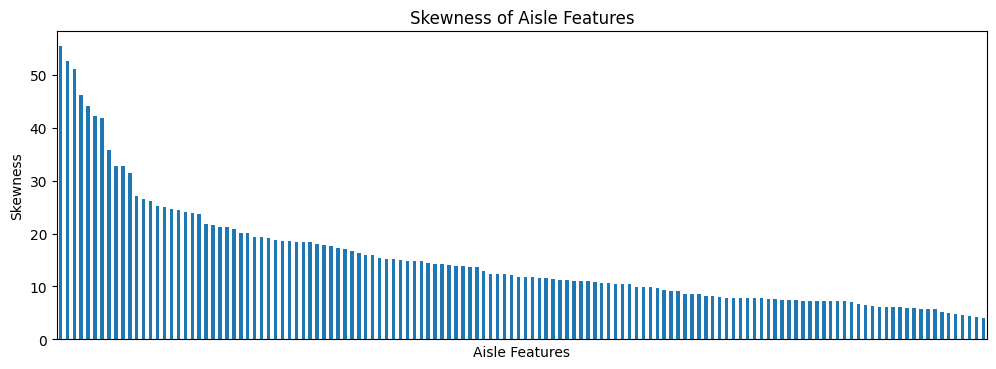

count    134.000000
mean      15.066676
std       10.237698
min        4.063232
25%        7.822887
50%       11.809843
75%       18.545011
max       55.393211
dtype: float64


In [4]:
# Check how skewed the original aisle purchase count features are

skew_counts = customer_aisle.skew()
skew_counts.sort_values(ascending=False).plot(kind="bar", figsize=(12, 4))
plt.title("Skewness of Aisle Features")
plt.xlabel("Aisle Features")
plt.ylabel("Skewness")
plt.xticks([])
plt.show()
print(skew_counts.describe())

In [5]:
# Apply log1p and check whether the feature distributions became less skewed
X_counts = customer_aisle.values.astype("float32")
X_log = np.log1p(X_counts)

X_log_df = pd.DataFrame(X_log, index=customer_aisle.index, columns=customer_aisle.columns)

skew_log = X_log_df.skew()

print("Skewness after log1p:")
print(skew_log.describe())

# Check mean and standard deviation
print("\nSummary statistics after log1p:")
print(X_log_df.describe())



Skewness after log1p:
count    134.000000
mean       3.747710
std        2.526105
min        0.046950
25%        1.687126
50%        2.866444
75%        5.426164
max       13.473565
dtype: float64

Summary statistics after log1p:
aisle  air fresheners candles    asian foods  baby accessories  \
count           206209.000000  206209.000000     206209.000000   
mean                 0.046548       0.327947          0.017615   
std                  0.234645       0.607765          0.149578   
min                  0.000000       0.000000          0.000000   
25%                  0.000000       0.000000          0.000000   
50%                  0.000000       0.000000          0.000000   
75%                  0.000000       0.693147          0.000000   
max                  4.007333       4.682131          3.871201   

aisle  baby bath body care  baby food formula  bakery desserts  \
count        206209.000000      206209.000000    206209.000000   
mean              0.022585           0.2607

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80/20 Train/Validation Split
X_train_log, X_val_log = train_test_split(X_log,test_size=0.20,random_state=42)
print("Train shape:", X_train_log.shape)
print("Validation shape:", X_val_log.shape)


# Standardize the log-transformed features using only the training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_log).astype("float32")
X_val = scaler.transform(X_val_log).astype("float32")

print("Final train input shape:", X_train.shape)
print("Final validation input shape:", X_val.shape)


Train shape: (164967, 134)
Validation shape: (41242, 134)
Final train input shape: (164967, 134)
Final validation input shape: (41242, 134)


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# Build an autoencoder with a mirrored decoder structure
input_dim = X_train.shape[1]

def build_autoencoder(input_dim, architecture):
    input_layer = layers.Input(shape=(input_dim,))
    x = input_layer

    for units in architecture:
        x = layers.Dense(units, activation="relu")(x)

    bottleneck = x

    for units in reversed(architecture[:-1]):
        x = layers.Dense(units, activation="relu")(x)

    output_layer = layers.Dense(input_dim, activation="linear")(x)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    encoder = Model(inputs=input_layer, outputs=bottleneck)

    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse"
    )

    return autoencoder, encoder

In [8]:
# Train and compare different bottleneck sizes
architectures = {
    "AE_64_5": [64, 5],
    "AE_64_10": [64, 10],
    "AE_64_16": [64, 16],
    "AE_64_20": [64, 20]
}

results = []
trained_models = {}

for name, architecture in architectures.items():

    early_stop = EarlyStopping(
        patience=5,
        restore_best_weights=True
    )


    autoencoder, encoder = build_autoencoder(input_dim, architecture)

    history = autoencoder.fit(
        X_train,
        X_train,
        validation_data=(X_val, X_val),
        epochs=200,
        batch_size=512,
        callbacks=[early_stop],
        verbose=1
    )



    best_val_loss = min(history.history["val_loss"])
    best_epoch = np.argmin(history.history["val_loss"]) + 1

    results.append({
        "model": name,
        "architecture": str(architecture),
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    })

    trained_models[name] = {
        "autoencoder": autoencoder,
        "encoder": encoder,
        "history": history
    }

Epoch 1/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8178 - val_loss: 0.7627
Epoch 2/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7382 - val_loss: 0.7342
Epoch 3/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7198 - val_loss: 0.7233
Epoch 4/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7115 - val_loss: 0.7169
Epoch 5/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7057 - val_loss: 0.7117
Epoch 6/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7009 - val_loss: 0.7071
Epoch 7/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6967 - val_loss: 0.7032
Epoch 8/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6931 - val_loss: 0.7000
Epoch 9/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6901 - val_loss: 0.6974
Epoch 10/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6877 - val_loss: 0.6953
Epoch 11/200
323/323 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6856 - val_loss: 0.6934
Epoch 12/200
323/323 ━━━━━━━━━━━━━━━━━━━━

In [9]:
# Select the model with the lowest validation loss
results_df = pd.DataFrame(results).sort_values("best_val_loss").reset_index(drop=True)

print("Architecture comparison:")
print(results_df)

best_model_name = results_df.loc[0, "model"]

print("\nBest model based on validation loss:")
print(best_model_name)

best_autoencoder = trained_models[best_model_name]["autoencoder"]
best_encoder = trained_models[best_model_name]["encoder"]

Architecture comparison:
      model architecture  best_val_loss  best_epoch
0  AE_64_20     [64, 20]       0.460496         200
1  AE_64_16     [64, 16]       0.476678         200
2  AE_64_10     [64, 10]       0.557079         200
3   AE_64_5      [64, 5]       0.661580         200

Best model based on validation loss:
AE_64_20


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use the best encoder to create latent representations for all customers
best_architecture = architectures[best_model_name]

print("Selected best architecture based on validation loss:")
print(best_model_name, best_architecture)

X_all = scaler.transform(X_log).astype("float32")
print("Full input shape:", X_all.shape)

Z_all = best_encoder.predict(X_all, batch_size=512)
print("Latent representation shape:", Z_all.shape)

Selected best architecture based on validation loss:
AE_64_20 [64, 20]
Full input shape: (206209, 134)
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step
Latent representation shape: (206209, 20)


In [11]:
# Evaluate different k values on the latent representations using Silhouette Score and inertia
k_results = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = kmeans.fit_predict(Z_all)

    k_results.append({
        "k": k,
        "silhouette_score": silhouette_score(Z_all, labels),
        "inertia": kmeans.inertia_})

k_results_df = pd.DataFrame(k_results)

print("K selection results:")
print(k_results_df)

K selection results:
    k  silhouette_score     inertia
0   2          0.595323  12337031.0
1   3          0.456712   9742136.0
2   4          0.357208   8651556.0
3   5          0.285373   8101672.5
4   6          0.285308   7675310.5
5   7          0.280731   7302405.0
6   8          0.226412   7008979.5
7   9          0.223556   6731549.0
8  10          0.226275   6535818.0


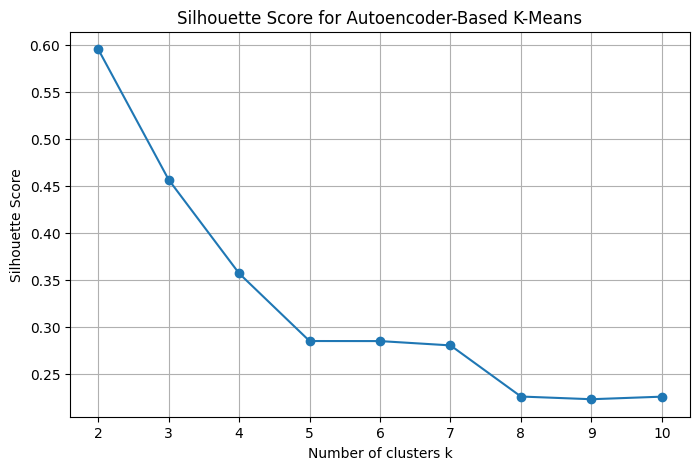

In [12]:
# Plot the Silhouette Scores for the tested k values
plt.figure(figsize=(8, 5))
plt.plot(k_results_df["k"], k_results_df["silhouette_score"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Autoencoder-Based K-Means")
plt.xticks(range(2, 11))
plt.grid(True)
plt.savefig("silhouette_score_autoencoder_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

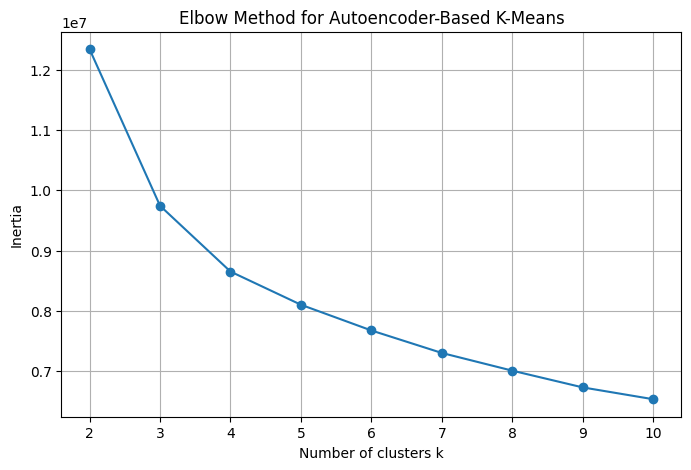

In [13]:
# Plot inertia values to inspect the elbow point
plt.figure(figsize=(8, 5))
plt.plot(k_results_df["k"], k_results_df["inertia"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Autoencoder-Based K-Means")
plt.xticks(range(2, 11))
plt.grid(True)
plt.savefig("elbow_method_autoencoder_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Fit the final K-Means model and assign the cluster labels back to the customer IDs
final_k = 4

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10)

final_cluster_labels = final_kmeans.fit_predict(Z_all)

customer_segments_ae = pd.DataFrame({
    "user_id": customer_aisle.index,
    "autoencoder_kmeans_segment": final_cluster_labels
})

print("Final cluster counts:")
print(customer_segments_ae["autoencoder_kmeans_segment"].value_counts().sort_index())

print("\nAutoencoder-based customer segments:")
print(customer_segments_ae.head())

#check mapping
print("Number of customers in customer_aisle:", customer_aisle.shape[0])
print("Number of assigned segment labels:", len(final_cluster_labels))
print("Number of customers in segment table:", customer_segments_ae["user_id"].nunique())

Final cluster counts:
autoencoder_kmeans_segment
0     57631
1    123348
2     20843
3      4387
Name: count, dtype: int64

Autoencoder-based customer segments:
   user_id  autoencoder_kmeans_segment
0        1                           1
1        2                           0
2        3                           1
3        4                           0
4        5                           1
Number of customers in customer_aisle: 206209
Number of assigned segment labels: 206209
Number of customers in segment table: 206209


In [15]:
customer_segments_ae.to_csv("autoencoder_kmeans_customer_segments.csv",index=False)